# MuTap — adaptive feedback cancellation, demonstrated

A microphone and a loudspeaker in the same room form a **closed loop**: the
speaker plays a processed copy of what the mic picks up, the room feeds it
back, and past a critical gain the loop rings up into a howl. **MuTap**
cancels the feedback path with an adaptive filter — but a naive adaptive
filter is *biased* in a closed loop (the speaker signal is correlated with
the very source you want to keep), so MuTap uses **PEM prewhitening**
(FDAF-PEM-AFROW: Rombouts et al. 2007, Gil-Cacho et al. 2014) to remove the
bias, plus IPC-gated adaptation control to survive real-world transients.

This notebook loads the library through its C ABI (`ctypes`, no Python
bindings required), runs the same closed-loop simulation as the test suite,
and *shows* what it does:

1. **Howling** — the loop pushed past its maximum stable gain (MSG)
2. **The bias problem** — a naive canceller vs the PEM canceller, same loop
3. **Added stable gain** — the deliverable metric, across program material
4. **IPC** — the double-talk indicator that gates adaptation
5. **Bursts** — adaptation control surviving a +20 dB near-end burst

Everything is deterministic (fixed seeds); re-running reproduces every figure.


In [1]:
import ctypes, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CAPI_DIR = REPO / "build" / "tools" / "capi"

def _find_dso():
    for name in ("libmutap_capi.so", "libmutap_capi.dylib", "mutap_capi.dll"):
        hits = sorted(CAPI_DIR.rglob(name))
        if hits:
            return hits[0]
    return None

def _run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed: " + " ".join(cmd))

DSO = _find_dso()
if DSO is None:  # build the C ABI shared library on first run
    _run(["cmake", "-B", str(REPO / "build"), "-S", str(REPO),
          "-DCMAKE_BUILD_TYPE=Release", "-DMUTAP_BUILD_CAPI=ON"])
    _run(["cmake", "--build", str(REPO / "build"), "--target", "mutap_capi",
          "--config", "Release", "-j"])
    DSO = _find_dso()
assert DSO is not None, "libmutap_capi not found after build"

_lib = ctypes.CDLL(str(DSO))
_d, _p, _s = ctypes.c_double, ctypes.POINTER(ctypes.c_double), ctypes.c_size_t
for fam in ("fdaf", "afc"):
    getattr(_lib, f"mutap_{fam}_create").restype = ctypes.c_void_p
    getattr(_lib, f"mutap_{fam}_create").argtypes = [_s, _s, _d, _d, ctypes.c_int, _d]
    getattr(_lib, f"mutap_{fam}_clone").restype = ctypes.c_void_p
    getattr(_lib, f"mutap_{fam}_clone").argtypes = [ctypes.c_void_p]
    getattr(_lib, f"mutap_{fam}_process").argtypes = [ctypes.c_void_p, _p, _p, _p]
    getattr(_lib, f"mutap_{fam}_impulse_response").argtypes = [ctypes.c_void_p, _p]
    getattr(_lib, f"mutap_{fam}_filter_length").restype = _s
    getattr(_lib, f"mutap_{fam}_filter_length").argtypes = [ctypes.c_void_p]
    getattr(_lib, f"mutap_{fam}_ipc").restype = _d
    getattr(_lib, f"mutap_{fam}_ipc").argtypes = [ctypes.c_void_p]
    getattr(_lib, f"mutap_{fam}_set_adaptation").argtypes = [ctypes.c_void_p, ctypes.c_int]
    getattr(_lib, f"mutap_{fam}_destroy").argtypes = [ctypes.c_void_p]

def _ptr(a):
    return a.ctypes.data_as(_p)

class Canceller:
    """ctypes wrapper over one canceller family ("fdaf" = naive, "afc" = PEM)."""
    def __init__(self, family, block=64, partitions=4, mu=0.0, rel_reg=-1.0,
                 ipc_scaling=False, transient_ratio=0.0, _handle=None):
        self.family = family
        self.h = _handle if _handle is not None else getattr(_lib, f"mutap_{family}_create")(
            block, partitions, mu, rel_reg, int(ipc_scaling), transient_ratio)
        assert self.h, "create failed (bad config?)"
        self.block = block
    def process(self, u, y):
        e = np.empty(self.block)
        getattr(_lib, f"mutap_{self.family}_process")(self.h, _ptr(np.ascontiguousarray(u)),
                                                      _ptr(np.ascontiguousarray(y)), _ptr(e))
        return e
    def impulse_response(self):
        ir = np.empty(getattr(_lib, f"mutap_{self.family}_filter_length")(self.h))
        getattr(_lib, f"mutap_{self.family}_impulse_response")(self.h, _ptr(ir))
        return ir
    def ipc(self):
        return getattr(_lib, f"mutap_{self.family}_ipc")(self.h)
    def freeze(self, frozen=True):
        getattr(_lib, f"mutap_{self.family}_set_adaptation")(self.h, int(not frozen))
    def clone(self):
        c = Canceller(self.family, block=self.block,
                      _handle=getattr(_lib, f"mutap_{self.family}_clone")(self.h))
        return c
    def __del__(self):
        if getattr(self, "h", None):
            getattr(_lib, f"mutap_{self.family}_destroy")(self.h)

def naive(**kw):  return Canceller("fdaf", **kw)
def pem(**kw):    return Canceller("afc", **kw)

# ---- plot style: validated categorical palette, fixed entity assignment ----
C_PEM, C_NAIVE, C_OPEN, C_TRUTH = "#2a78d6", "#1baf7a", "#eda100", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
                     "lines.linewidth": 2.0, "font.size": 10})
print("MuTap C ABI version:", _lib.mutap_version())

MuTap C ABI version: 100


## The closed loop

$$y(n) = v(n) + F(q)\,u(n) \qquad e(n) = y(n) - \hat F(q)\,u(n) \qquad u(n) = K\,e(n-d)$$

The mic signal $y$ is the near-end source $v$ (the talker/instrument — the
signal we want) plus the room's feedback path $F$ applied to the loudspeaker
signal $u$. The canceller subtracts its estimate $\hat F(q)\,u$; the forward
path amplifies the cleaned signal by $K$ with $d$ samples of delay and sends
it to the speaker. Below: the same deterministic block-synchronous simulation
the test suite uses — a synthetic 256-tap decaying room response as $F$, and
the true-path convolution at sample resolution. At 48 kHz the 64-sample
blocks are 1.3 ms and the 256-tap path is 5.3 ms of room.

The loop's **maximum stable gain** (MSG) without a canceller is bounded by
$-20\log_{10}\max_\omega|F(\omega)|$; a canceller's job is measured by the
**added stable gain** (ASG) it buys beyond that.

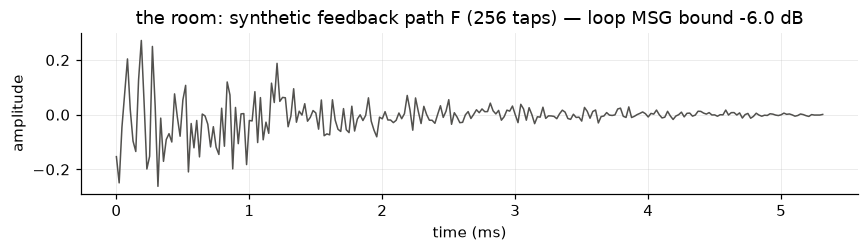

In [2]:
FS, BLOCK, PARTS = 48000, 64, 4
TAPS = BLOCK * PARTS

def decaying_rir(taps=TAPS, seed=5):
    rng = np.random.default_rng(seed)
    f = rng.standard_normal(taps) * np.exp(-np.arange(taps) / (taps / 4))
    return f / np.sqrt(np.sum(f * f))

def white(n, seed):
    return np.random.default_rng(seed).standard_normal(n)

def tonal(n, seed):
    """Three incommensurate sinusoids, unit RMS, -40 dB noise floor."""
    t = np.arange(n)
    s = np.sqrt(2 / 3) * (np.sin(0.031 * 2 * np.pi * t + 0.1)
                          + np.sin(0.093 * 2 * np.pi * t + 1.3)
                          + np.sin(0.171 * 2 * np.pi * t + 2.9))
    return s + 0.01 * white(n, seed)

def _ar4(x):  # two resonator pole pairs (speech-envelope-like coloring)
    out = np.empty_like(x)
    s1 = [0.0, 0.0]; s2 = [0.0, 0.0]
    a1 = (-2 * 0.97 * np.cos(0.03 * 2 * np.pi), 0.97 ** 2)
    a2 = (-2 * 0.95 * np.cos(0.11 * 2 * np.pi), 0.95 ** 2)
    for i, w in enumerate(x):
        w = w - a1[0] * s1[0] - a1[1] * s1[1]; s1[1], s1[0] = s1[0], w
        w = w - a2[0] * s2[0] - a2[1] * s2[1]; s2[1], s2[0] = s2[0], w
        out[i] = w
    return out

def speech_env(n, seed):
    x = _ar4(white(n, seed))
    return x / np.sqrt(np.mean(x * x))

def voiced(n, seed, period=160):
    exc = np.zeros(n); exc[::period] = np.sqrt(period)
    x = _ar4(exc + 0.01 * white(n, seed))
    return x / np.sqrt(np.mean(x * x))

class ClosedLoop:
    def __init__(self, path, gain_db, block=BLOCK, delay=2 * BLOCK, clip=1000.0):
        self.f, self.b, self.d, self.clip = np.asarray(path), block, delay, clip
        self.set_gain_db(gain_db)
        self.u_hist = np.zeros(len(path) - 1 + block)
        self.e_hist = np.zeros(delay)
    def set_gain_db(self, k_db):
        self.gain = 10 ** (k_db / 20)
    def step(self, v, canceller=None):
        b = self.b
        u = np.clip(np.nan_to_num(self.gain * self.e_hist[:b], posinf=self.clip, neginf=-self.clip),
                    -self.clip, self.clip)
        self.u_hist[len(self.f) - 1:] = u
        y = v + np.convolve(self.u_hist, self.f[::-1], mode="valid")
        self.u_hist[:len(self.f) - 1] = self.u_hist[b:].copy()[:len(self.f) - 1]
        e = canceller.process(u, y) if canceller is not None else y.copy()
        self.e_hist = np.concatenate([self.e_hist[b:], e])
        return u, y, e

def theoretical_msg_db(f):
    return -20 * np.log10(np.abs(np.fft.rfft(f, 8192)).max())

def misalignment_db(truth, est):
    return 10 * np.log10(np.sum((truth - est) ** 2) / np.sum(truth ** 2))

def run_loop(path, gain_db, v, canceller=None, howl_rms=100.0):
    """Run v through the loop; returns (e trace, block RMS trace, howled)."""
    loop = ClosedLoop(path, gain_db)
    blocks = len(v) // BLOCK
    e_trace = np.empty(blocks * BLOCK); rms = np.empty(blocks); howled = False
    for k in range(blocks):
        _, _, e = loop.step(v[k * BLOCK:(k + 1) * BLOCK], canceller)
        e_trace[k * BLOCK:(k + 1) * BLOCK] = e
        rms[k] = np.sqrt(np.mean(e * e))
        howled = howled or rms[k] >= howl_rms
    return e_trace, rms, howled

def measured_msg_db(path, template, v, lo, hi, tol=0.5):
    """Bisect the forward gain; each probe runs a fresh clone of `template`."""
    def howls(k_db):
        c = template.clone() if template is not None else None
        return run_loop(path, k_db, v, c)[2]
    if howls(lo):
        return lo
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        lo, hi = (lo, mid) if howls(mid) else (mid, hi)
    return lo

F = decaying_rir()
MSG = theoretical_msg_db(F)
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.plot(np.arange(TAPS) / FS * 1000, F, color=C_TRUTH, lw=1.0)
ax.set_xlabel("time (ms)"); ax.set_ylabel("amplitude")
ax.set_title(f"the room: synthetic feedback path F (256 taps) — loop MSG bound {MSG:+.1f} dB")
plt.tight_layout(); plt.show()

## 1. Howling

No canceller. The forward gain ramps slowly from 8 dB below the MSG bound to
6 dB above it. Watch the loop cross from quietly regenerative to screaming:
the spectrogram collapses to the single loop resonance that wins the race,
and the level slams into the loudspeaker limiter. This is the failure mode
everything below exists to prevent — and the measured onset lands where the
$-20\log_{10}\max|F(\omega)|$ bound says it should.

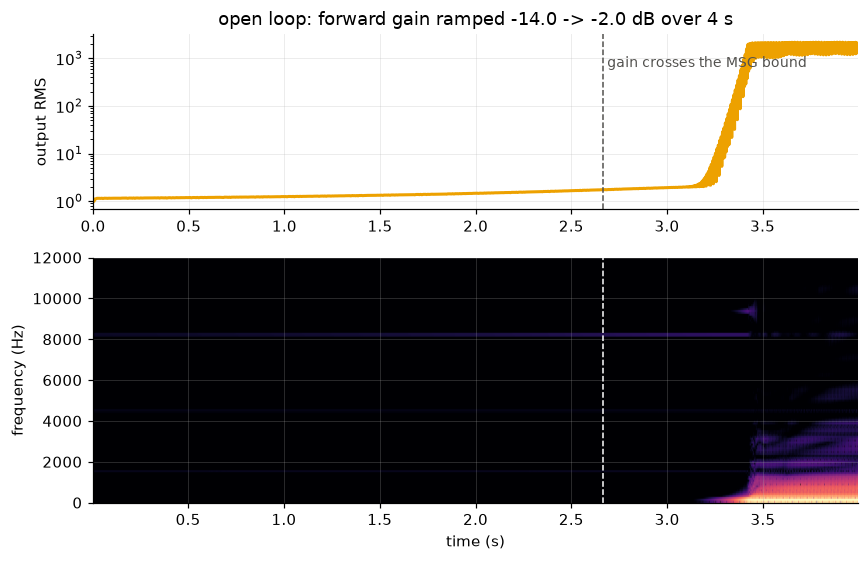

howl onset at forward gain -4.0 dB — MSG bound -6.0 dB (onset trails the bound slightly: near threshold the ring-up is slow)


In [3]:
BLOCKS_RAMP = 3000
v = tonal(BLOCKS_RAMP * BLOCK, seed=2)
gains = np.linspace(MSG - 8, MSG + 4, BLOCKS_RAMP)
loop = ClosedLoop(F, gains[0])
e_trace = np.empty(BLOCKS_RAMP * BLOCK); rms = np.empty(BLOCKS_RAMP)
for k in range(BLOCKS_RAMP):
    loop.set_gain_db(gains[k])
    _, _, e = loop.step(v[k * BLOCK:(k + 1) * BLOCK])
    e_trace[k * BLOCK:(k + 1) * BLOCK] = e
    rms[k] = np.sqrt(np.mean(e * e))

t_blocks = np.arange(BLOCKS_RAMP) * BLOCK / FS
t_msg = t_blocks[np.argmax(gains >= MSG)]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.2),
                               gridspec_kw={"height_ratios": [1, 1.4]})
ax1.semilogy(t_blocks, rms, color=C_OPEN)
ax1.axvline(t_msg, color=C_TRUTH, ls="--", lw=1)
ax1.annotate(" gain crosses the MSG bound", (t_msg, rms.max() * 0.3), fontsize=9, color=C_TRUTH)
ax1.set_ylabel("output RMS"); ax1.set_xlim(0, t_blocks[-1])
ax1.set_title(f"open loop: forward gain ramped {MSG - 8:+.1f} -> {MSG + 4:+.1f} dB over {t_blocks[-1]:.0f} s")
ax2.specgram(e_trace, NFFT=512, Fs=FS, noverlap=384, cmap="magma", vmin=-30)
ax2.axvline(t_msg, color="white", ls="--", lw=1)
ax2.set_ylim(0, 12000)
ax2.set_ylabel("frequency (Hz)"); ax2.set_xlabel("time (s)")
plt.tight_layout(); plt.show()
onset = gains[np.argmax(rms >= 100)] if (rms >= 100).any() else np.nan
print(f"howl onset at forward gain {onset:+.1f} dB — MSG bound {MSG:+.1f} dB "
      "(onset trails the bound slightly: near threshold the ring-up is slow)")

## 2. The bias problem — a gain staircase

Both cancellers now adapt inside the loop while the near-end source plays
**tonal** program material (three steady sinusoids — sustained notes through
a PA). The loudspeaker signal is a delayed, filtered copy of that near-end
source, so a **naive** adaptive filter can't tell feedback from music: its
update is biased toward cancelling the music itself. The **PEM** canceller
re-fits a near-end model every block (short-term LP + pitch predictor) and
prewhitens both signals before its update, which removes the bias.

The forward gain steps up every 1.3 s: **MSG − 6 → MSG → MSG + 6 dB**. The
naive canceller erupts at a gain the bare room handles; the PEM canceller
rides quietly through a gain 6 dB *above* the open-loop limit — and its room
estimate *improves* with each step, because a louder loop means more feedback
signal to identify from. (Neither estimate gets a deep broadband misalignment
in a closed loop at these gains — the feedback is quiet relative to the music,
and tonal material only excites the path at a few frequencies. Unbiased
*tracking* is what buys stable gain, not a one-time perfect fit; the naive
estimate is worse than having no filter at all, the dotted line.)

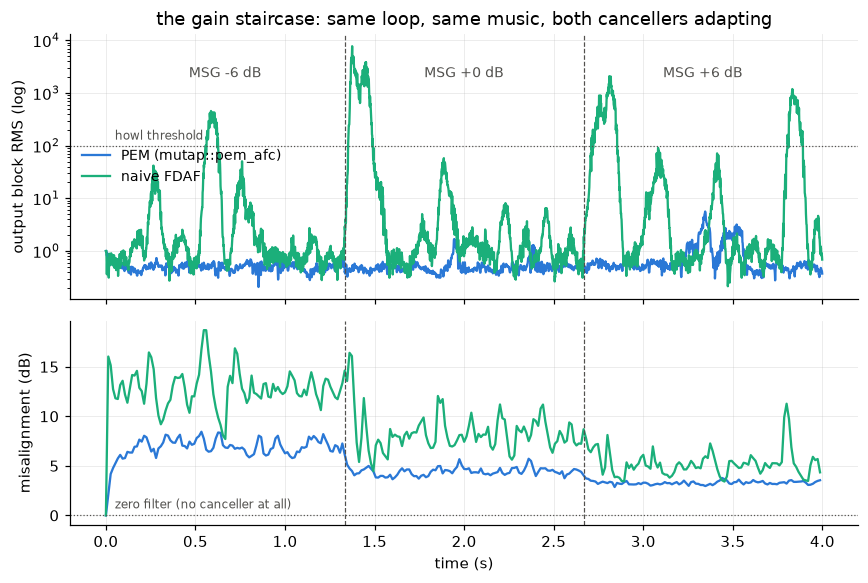

In [4]:
STAGES = [(MSG - 6, 1000), (MSG, 1000), (MSG + 6, 1000)]
BLOCKS_ID = sum(nb for _, nb in STAGES)
v = tonal(BLOCKS_ID * BLOCK, seed=2)
results = {}
for name, factory, col in (("PEM (mutap::pem_afc)", pem, C_PEM),
                           ("naive FDAF", lambda: naive(rel_reg=0.0), C_NAIVE)):
    c = factory()
    loop = ClosedLoop(F, STAGES[0][0])
    rms = np.empty(BLOCKS_ID); mis = []
    k = 0
    for gain_db, n_blocks in STAGES:
        loop.set_gain_db(gain_db)
        for _ in range(n_blocks):
            _, _, e = loop.step(v[k * BLOCK:(k + 1) * BLOCK], c)
            rms[k] = np.sqrt(np.mean(e * e))
            if k % 10 == 0:
                mis.append(misalignment_db(F, c.impulse_response()))
            k += 1
    results[name] = (rms, mis, col)

t = np.arange(BLOCKS_ID) * BLOCK / FS
edges = np.cumsum([0] + [nb for _, nb in STAGES]) * BLOCK / FS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.4), sharex=True,
                               gridspec_kw={"height_ratios": [1.3, 1]})
for name, (rms, mis, col) in results.items():
    ax1.semilogy(t, rms, color=col, label=name, lw=1.5)
    ax2.plot(np.arange(0, BLOCKS_ID, 10) * BLOCK / FS, mis, color=col, lw=1.5)
for ax in (ax1, ax2):
    for edge in edges[1:-1]:
        ax.axvline(edge, color=C_TRUTH, ls="--", lw=0.8)
for (gain_db, _), x0, x1 in zip(STAGES, edges[:-1], edges[1:]):
    ax1.annotate(f"MSG {gain_db - MSG:+.0f} dB", ((x0 + x1) / 2, 2e3), ha="center",
                 fontsize=9, color=C_TRUTH)
ax1.axhline(100, color=C_TRUTH, lw=0.8, ls=":")
ax1.annotate("howl threshold", (0.05, 130), fontsize=8, color=C_TRUTH)
ax1.set_ylabel("output block RMS (log)")
ax1.set_title("the gain staircase: same loop, same music, both cancellers adapting")
ax1.legend(fontsize=9, frameon=False, loc="center left")
ax2.axhline(0, color=C_TRUTH, lw=0.8, ls=":")
ax2.annotate("zero filter (no canceller at all)", (0.05, 0.7), fontsize=8, color=C_TRUTH)
ax2.set_xlabel("time (s)"); ax2.set_ylabel("misalignment (dB)")
plt.tight_layout(); plt.show()

## 3. Added stable gain — the scoreboard

Converge each canceller in the loop at MSG − 6 dB, then bisect the forward
gain (fresh clone per probe, adaptation live) for the highest gain that does
not howl. **ASG = that gain minus the open-loop MSG.** Positive: the canceller
lets you turn the system up beyond what the bare room allows. Negative: the
canceller is *destabilizing* — worse than nothing. This is the M2/M3 test
suite's measurement, reproduced: the naive canceller only survives
uncorrelated (white) near-end; PEM is positive on everything, including the
tonal and voiced material where naive howls below the open-loop limit.

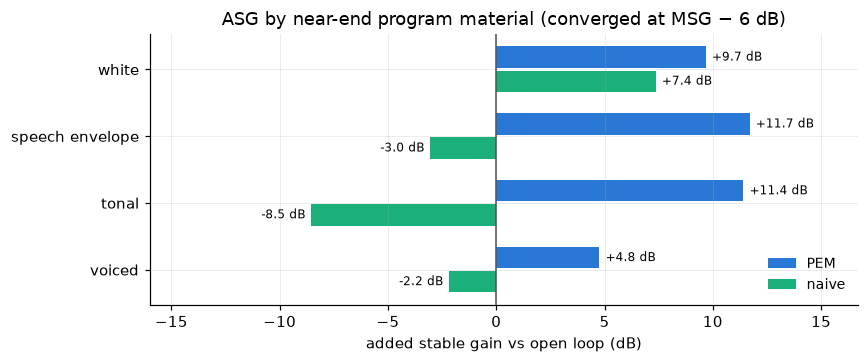

In [5]:
MATERIALS = [("white", white), ("speech envelope", speech_env), ("tonal", tonal), ("voiced", voiced)]
SEARCH_LO, SEARCH_HI = MSG - 12, MSG + 25
asg = {"PEM": [], "naive": []}
for mname, gen in MATERIALS:
    v_conv, v_probe = gen(1500 * BLOCK, 2), gen(400 * BLOCK, 12)
    for cname, factory in (("PEM", pem), ("naive", lambda: naive(rel_reg=0.0))):
        c = factory()
        loop = ClosedLoop(F, MSG - 6)
        for k in range(1500):
            loop.step(v_conv[k * BLOCK:(k + 1) * BLOCK], c)
        asg[cname].append(measured_msg_db(F, c, v_probe, SEARCH_LO, SEARCH_HI) - MSG)

fig, ax = plt.subplots(figsize=(8, 3.4))
ypos = np.arange(len(MATERIALS), dtype=float)
for i, (cname, col, off) in enumerate((("PEM", C_PEM, -0.18), ("naive", C_NAIVE, 0.18))):
    vals = asg[cname]
    ax.barh(ypos + off, vals, height=0.32, color=col, label=cname)
    for y, val in zip(ypos + off, vals):
        floored = " (search floor)" if abs(val - (SEARCH_LO - MSG)) < 0.6 else ""
        ax.annotate(f"{val:+.1f} dB{floored}", (val, y), va="center", fontsize=8,
                    ha="left" if val >= 0 else "right",
                    xytext=(4 if val >= 0 else -4, 0), textcoords="offset points")
ax.axvline(0, color=C_TRUTH, lw=1)
ax.set_yticks(ypos, [m for m, _ in MATERIALS]); ax.invert_yaxis()
ax.set_xlabel("added stable gain vs open loop (dB)")
ax.set_title("ASG by near-end program material (converged at MSG − 6 dB)")
ax.legend(fontsize=9, frameon=False, loc="lower right")
ax.set_xlim(SEARCH_LO - MSG - 4, max(max(asg["PEM"]), max(asg["naive"])) + 5)
plt.tight_layout(); plt.show()

## 4. IPC — knowing when to adapt

The **instantaneous pseudo-correlation** (Gil-Cacho et al. 2014) is MuTap's
double-talk indicator: a chance-corrected coherence estimating the *fraction
of error power still coherent with the loudspeaker signal*. High = the error
is unmodeled feedback (informative — adapt hard). Low = the error is the
near-end source (adapting would inject bias — hold). It comes almost free
from spectra the FDAF already has.

Left: an open-loop echo canceller converging, then hit with double-talk.
Right: the 2014 paper's headline, reproduced in the feedback loop — PEM
prewhitening collapses the correlation that biases the naive update.

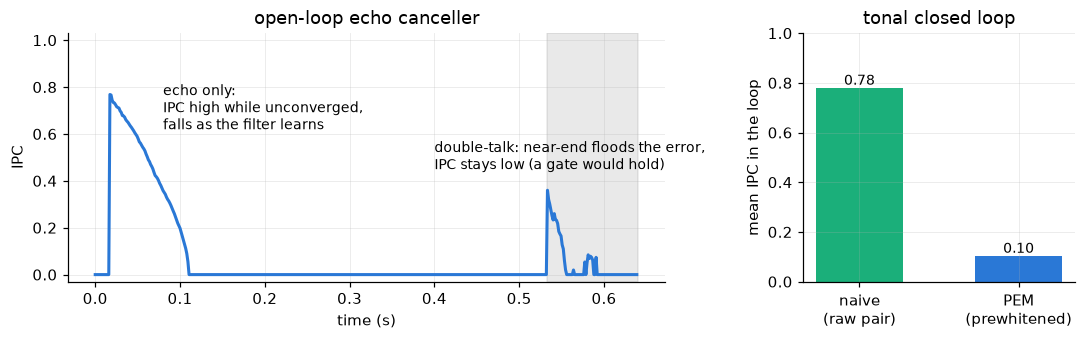

In [6]:
# left: open-loop AEC — echo only, then double-talk
u = white(480 * BLOCK, 1); talk = white(480 * BLOCK, 9)
d = np.convolve(u, F)[:len(u)]
c = naive()
ipc_trace = np.empty(480)
for k in range(480):
    sl = slice(k * BLOCK, (k + 1) * BLOCK)
    desired = d[sl] + (3.0 * talk[sl] if k >= 400 else 0.0)
    c.process(u[sl], desired)
    ipc_trace[k] = c.ipc()

# right: mean IPC inside the tonal closed loop, naive raw pair vs PEM prewhitened pair
loop_ipc = {}
v = tonal(600 * BLOCK, 2)
for name, c2 in (("naive\n(raw pair)", naive(rel_reg=0.0)), ("PEM\n(prewhitened)", pem())):
    loop = ClosedLoop(F, MSG - 6)
    vals = []
    for k in range(600):
        loop.step(v[k * BLOCK:(k + 1) * BLOCK], c2)
        if k >= 100:
            vals.append(c2.ipc())
    loop_ipc[name] = np.mean(vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={"width_ratios": [2.2, 1]})
t = np.arange(480) * BLOCK / FS
ax1.plot(t, ipc_trace, color=C_PEM)
ax1.axvspan(400 * BLOCK / FS, 480 * BLOCK / FS, color=C_TRUTH, alpha=0.12)
ax1.annotate("echo only:\nIPC high while unconverged,\nfalls as the filter learns", (0.08, 0.62), fontsize=9)
ax1.annotate("double-talk: near-end floods the error,\nIPC stays low (a gate would hold)", (0.40, 0.45), fontsize=9)
ax1.set_xlabel("time (s)"); ax1.set_ylabel("IPC"); ax1.set_ylim(-0.03, 1.03)
ax1.set_title("open-loop echo canceller")
names = list(loop_ipc)
ax2.bar(names, [loop_ipc[n] for n in names], color=[C_NAIVE, C_PEM], width=0.55)
for i, n in enumerate(names):
    ax2.annotate(f"{loop_ipc[n]:.2f}", (i, loop_ipc[n]), ha="center", va="bottom", fontsize=9)
ax2.set_ylim(0, 1); ax2.set_ylabel("mean IPC in the loop")
ax2.set_title("tonal closed loop")
plt.tight_layout(); plt.show()

## 5. Surviving bursts

Real rooms have door slams and fortissimo entrances. Here the tonal near-end
jumps **+20 dB for 50 blocks** (67 ms) while the PEM canceller sits converged
in the loop. Ungated, those blocks have terrible update SNR: the filter is
wrecked, the loop rings up, and it takes seconds to recover. With M4's
adaptation control — the IPC-scaled step plus the instantaneous transient
gate — the canceller simply *holds* through the burst.

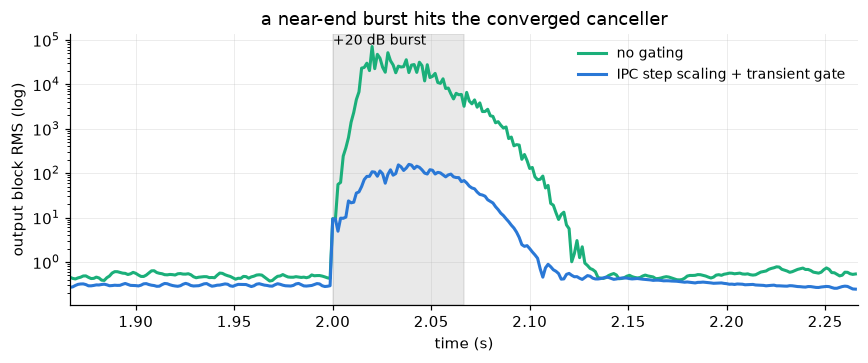

worst block RMS through the burst: ungated 71,240, gated 157.5


In [7]:
def burst_run(gated):
    kw = dict(ipc_scaling=True, transient_ratio=4.0) if gated else {}
    c = pem(**kw)
    loop = ClosedLoop(F, MSG - 6)
    v = tonal(1700 * BLOCK, 2)
    rms = np.empty(1700)
    for k in range(1700):
        vb = v[k * BLOCK:(k + 1) * BLOCK] * (10.0 if 1500 <= k < 1550 else 1.0)
        _, _, e = loop.step(vb, c)
        rms[k] = np.sqrt(np.mean(e * e))
    return rms

rms_open = burst_run(gated=False)
rms_gated = burst_run(gated=True)
t = np.arange(1700) * BLOCK / FS
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.semilogy(t, rms_open, color=C_NAIVE, label="no gating")
ax.semilogy(t, rms_gated, color=C_PEM, label="IPC step scaling + transient gate")
ax.axvspan(1500 * BLOCK / FS, 1550 * BLOCK / FS, color=C_TRUTH, alpha=0.12)
ax.annotate("+20 dB burst", (1500 * BLOCK / FS, rms_open.max() * 1.1), fontsize=9)
ax.set_xlim(1400 * BLOCK / FS, 1700 * BLOCK / FS)
ax.set_xlabel("time (s)"); ax.set_ylabel("output block RMS (log)")
ax.set_title("a near-end burst hits the converged canceller")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()
print(f"worst block RMS through the burst: ungated {rms_open[1500:1650].max():,.0f}, "
      f"gated {rms_gated[1500:1650].max():,.1f}")

## Where this goes next

- The same float core runs unchanged on the embedded targets (Cortex-M55 /
  Hexagon) — the plan and milestones live in [`HANDOFF.md`](../HANDOFF.md).
- Every number in this notebook is locked down as a regression test in
  [`tests/`](../tests): the closed-loop harness, the M2 naive-bias baseline,
  the M3 PEM pass criteria, and the M4 adaptation-control behavior.
- The Max/MSP external (`mutap.defeed~`, in
  [MuTap-Max](https://github.com/tap/MuTap-Max)) wraps `mutap::pem_afc`
  exactly as driven here.

**Papers:** Rombouts, van Waterschoot & Moonen, *JAES* 55(11), 2007
(PEM-AFROW) · Gil-Cacho, van Waterschoot, Moonen & Jensen, *IEEE/ACM TASLP*
22(12), 2014 (FDAF-PEM-AFROW, IPC) · van Waterschoot & Moonen, *Proc. IEEE*
99(2), 2011 (the 50-year survey).